# Sistema Inteligente de Monitoramento de Estresse Estudantil

## Análise Preditiva de Níveis de Estresse em Estudantes

### Contexto
Este notebook faz parte do projeto acadêmico da disciplina **Sistemas Inteligentes Aplicados** (UTFPR-DV).
O objetivo é construir um modelo de Machine Learning capaz de classificar o nível de estresse de estudantes
com base em variáveis comportamentais, psicológicas e acadêmicas.

### Base de Dados
Dataset: *Student Stress Monitoring Datasets* (Kaggle)

### Etapas deste Notebook
1. Configuração do Ambiente e Carga de Dados
2. Tratamento de Dados e Limpeza 
3. Análise Exploratória de Dados e Engenharia de Atributos
4. Construção e Treinamento dos Modelos de IA
5. Avaliação de Desempenho e Validação
6. Exportação dos Resultado Final

---
## 1. Configuração do Ambiente e Carga de Dados

Nesta seção, importamos todas as bibliotecas necessárias e carregamos o dataset
para inspeção inicial.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [3]:
DATA_PATH = os.path.join('data', 'StressLevelDataset.csv')

df = pd.read_csv(DATA_PATH)

print(f'Dataset carregado')
print(f'Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas')
print(f'\nPrimeiras 5 linhas:')
display(df.head())

print(f'\nInformações do dataset:')
print(df.info())

print(f'\nEstatísticas descritivas:')
display(df.describe())

Dataset carregado
Dimensões: 1100 linhas x 21 colunas

Primeiras 5 linhas:


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1



Informações do dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load         

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,...,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,...,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000


In [ ]:
TARGET_COLUMN = 'stress_level'
feature_columns = [col for col in df.columns if col != TARGET_COLUMN]

print(f'Coluna alvo: {TARGET_COLUMN}')
print(f'\nColunas preditivas ({len(feature_columns)} no total):')
for i, col in enumerate(feature_columns, 1):
    print(f'  {i:2d}. {col}')

print(f'\nDistribuição da variável alvo:')
print(df[TARGET_COLUMN].value_counts().sort_index())

print(f'\nMapeamento:')
target_mapping = {0: 'Baixo (0)', 1: 'Médio (1)', 2: 'Alto (2)'}
for k, v in target_mapping.items():
    print(f'  {k} -> {v}')

Coluna alvo (target): stress_level

Colunas preditivas (20 no total):
   1. anxiety_level
   2. self_esteem
   3. mental_health_history
   4. depression
   5. headache
   6. blood_pressure
   7. sleep_quality
   8. breathing_problem
   9. noise_level
  10. living_conditions
  11. safety
  12. basic_needs
  13. academic_performance
  14. study_load
  15. teacher_student_relationship
  16. future_career_concerns
  17. social_support
  18. peer_pressure
  19. extracurricular_activities
  20. bullying

Distribuição da variável alvo:
stress_level
0    373
1    358
2    369
Name: count, dtype: int64

Mapeamento:
  0 -> Baixo (0)
  1 -> Médio (1)
  2 -> Alto (2)


---
## 2. Tratamento de Dados e Limpeza (Data Cleaning)

Nesta seção, identificamos e tratamos valores ausentes, outliers e
inconsistências nos dados para garantir a qualidade do treinamento.

In [5]:
def diagnosticar_valores_ausentes(df):
    """Identifica e reporta valores ausentes no DataFrame."""
    nulos = df.isnull().sum()
    percentual = (df.isnull().sum() / len(df)) * 100
    tabela_nulos = pd.DataFrame({
        'Valores Ausentes': nulos,
        'Percentual (%)': percentual.round(2)
    })
    tabela_nulos = tabela_nulos[tabela_nulos['Valores Ausentes'] > 0]
    return tabela_nulos


def detectar_outliers_iqr(df, coluna):
    """Detecta outliers usando o método do Intervalo Interquartil (IQR)."""
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]
    return len(outliers), limite_inferior, limite_superior


nulos = diagnosticar_valores_ausentes(df)
if len(nulos) > 0:
    print('Valores ausentes encontrados:')
    display(nulos)
else:
    print('Nenhum valor ausente encontrado. O dataset está completo.')

Nenhum valor ausente encontrado. O dataset está completo.


In [6]:
# Detecção de outliers em todas as colunas
print('Detecção de outliers (método IQR) por coluna:')
print('-' * 60)

total_outliers = 0
for col in feature_columns:
    qtd, lim_inf, lim_sup = detectar_outliers_iqr(df, col)
    if qtd > 0:
        total_outliers += qtd
        print(f'{col:35s} -> {qtd:3d} outliers  (limites: [{lim_inf:.1f}, {lim_sup:.1f}])')

print('-' * 60)
print(f'Total de outliers encontrados: {total_outliers}')

# Remover outliers de todas as colunas para melhorar a qualidade dos dados
df_clean = df.copy()
for col in feature_columns:
    qtd, lim_inf, lim_sup = detectar_outliers_iqr(df_clean, col)
    df_clean = df_clean[(df_clean[col] >= lim_inf) & (df_clean[col] <= lim_sup)]

print(f'\nLinhas após remoção de outliers: {len(df_clean)} (removidas {len(df) - len(df_clean)})')

duplicatas = df_clean.duplicated().sum()
print(f'Linhas duplicadas: {duplicatas}')

print(f'\nDistribuição da variável alvo após limpeza:')
print(df_clean[TARGET_COLUMN].value_counts().sort_index())

# Usar o dataset limpo daqui em diante
df = df_clean

Detecção de outliers (método IQR) por coluna:
------------------------------------------------------------
noise_level                         -> 173 outliers  (limites: [0.5, 4.5])
living_conditions                   ->  62 outliers  (limites: [0.5, 4.5])
study_load                          -> 165 outliers  (limites: [0.5, 4.5])
------------------------------------------------------------
Total de outliers encontrados: 400

Linhas após remoção de outliers: 645 (removidas 455)
Linhas duplicadas: 0

Distribuição da variável alvo após limpeza:
stress_level
0    304
1    302
2     39
Name: count, dtype: int64


---
## 3. Análise Exploratória de Dados e Engenharia de Atributos

A EDA nos permite compreender os padrões, distribuições e correlações
entre as variáveis, fundamentando a escolha dos atributos mais relevantes
para o modelo preditivo.

Distribuição das variáveis preditivas por nível de estresse (após limpeza):


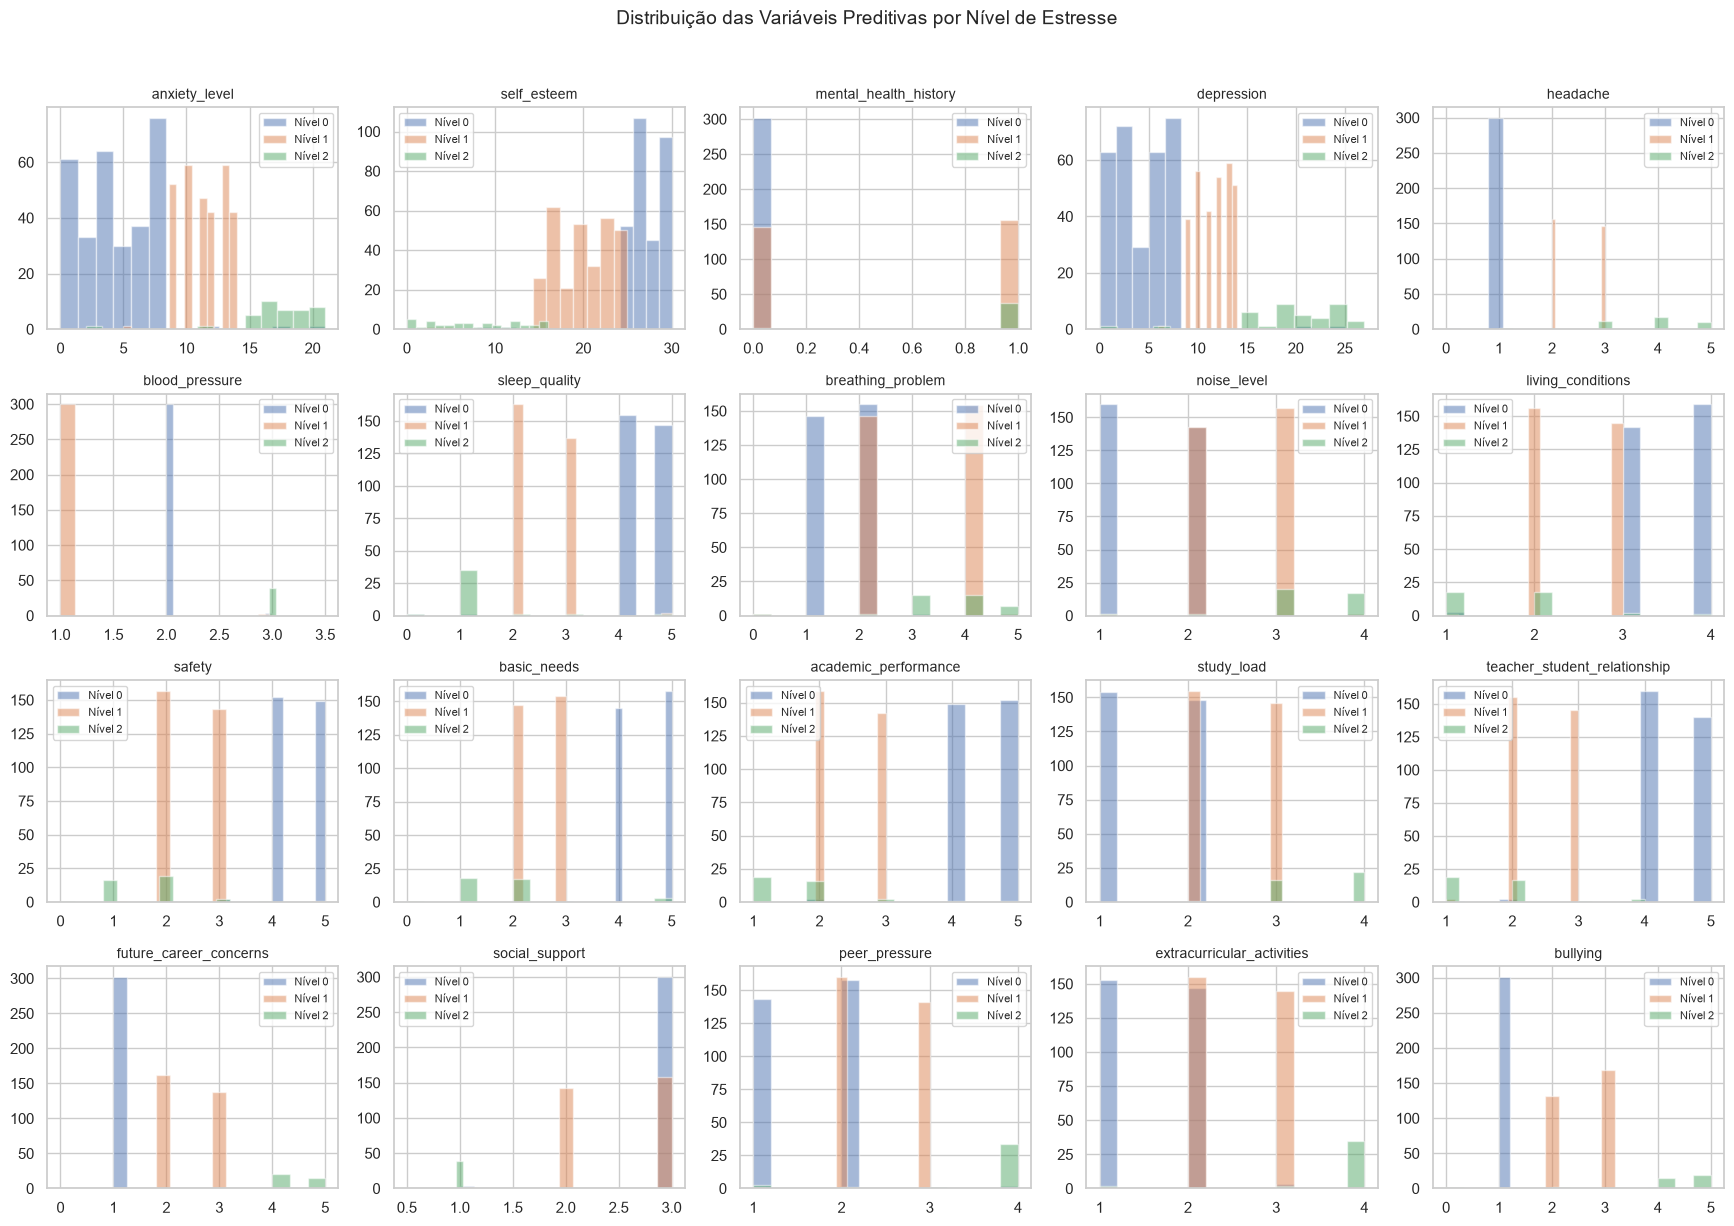

In [7]:

def plotar_histogramas(df, colunas, target_col, n_cols=5):
    """Plota histogramas das variáveis preditivas coloridos pela variável alvo."""
    n_linhas = int(np.ceil(len(colunas) / n_cols))
    fig, axes = plt.subplots(n_linhas, n_cols, figsize=(n_cols * 3.5, n_linhas * 3))
    axes = axes.flatten()

    for i, col in enumerate(colunas):
        for nivel in sorted(df[target_col].unique()):
            subset = df[df[target_col] == nivel][col]
            axes[i].hist(subset, alpha=0.5, label=f'Nível {nivel}', bins=15)
        axes[i].set_title(col, fontsize=10)
        axes[i].legend(fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribuição das Variáveis Preditivas por Nível de Estresse',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


print('Distribuição das variáveis preditivas por nível de estresse (após limpeza):')
plotar_histogramas(df, feature_columns, TARGET_COLUMN)

Matriz de Correlação de Pearson:


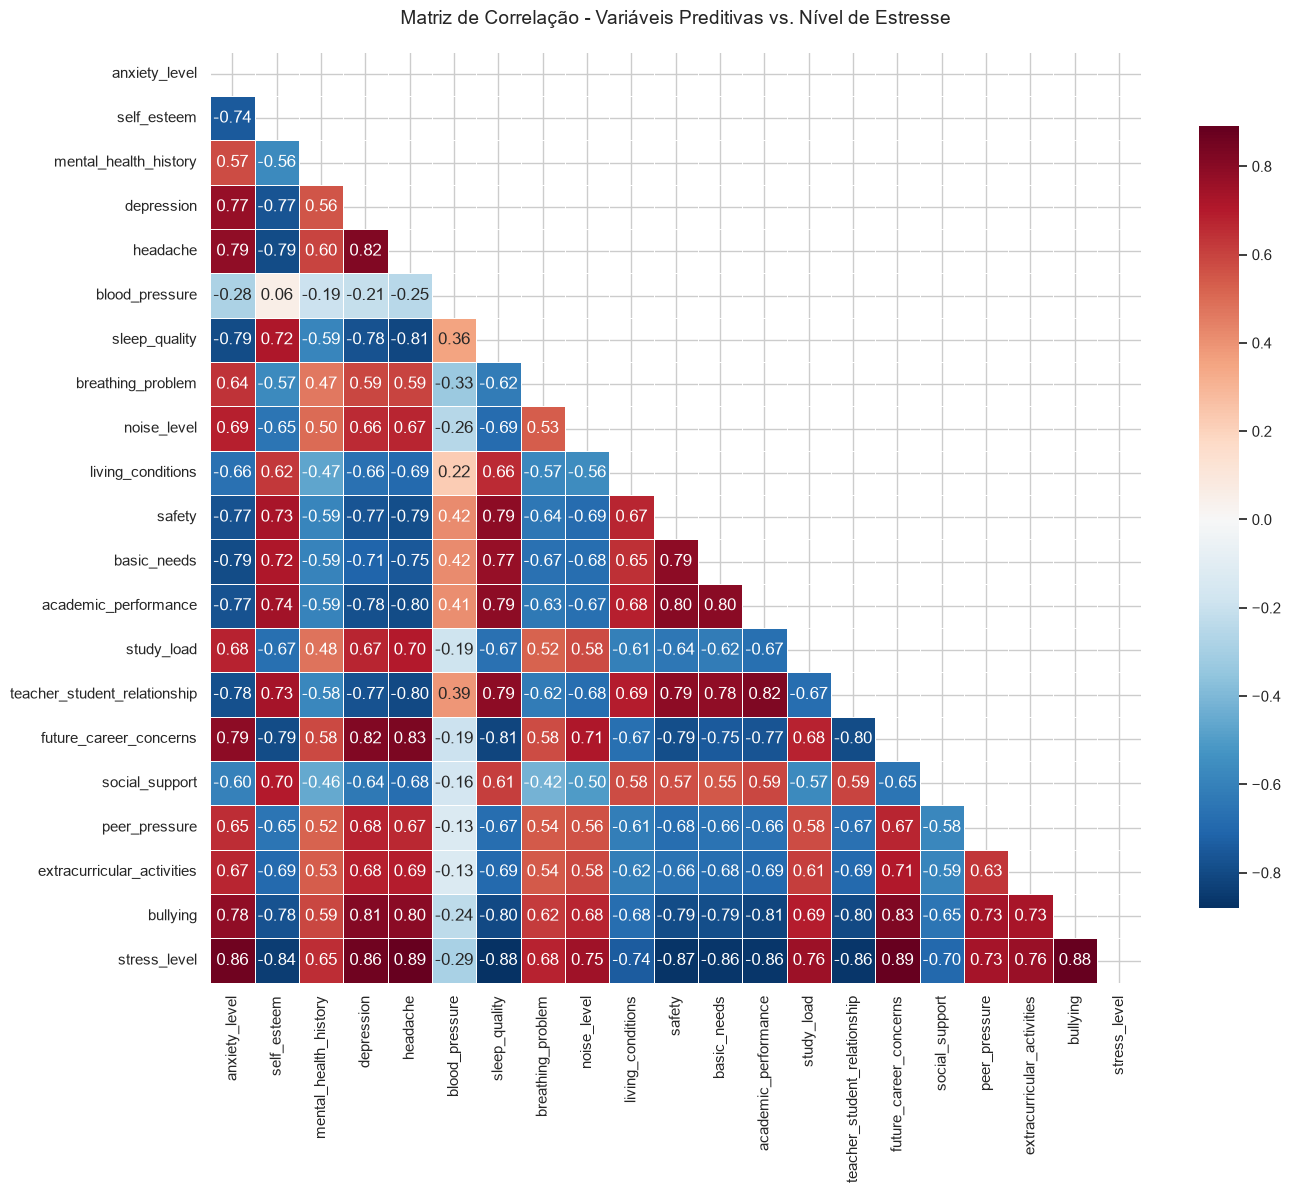

In [8]:
# Matriz de Correlação de Pearson
print('Matriz de Correlação de Pearson:')

correlacoes = df[feature_columns + [TARGET_COLUMN]].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlacoes, dtype=bool))
sns.heatmap(correlacoes, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlação - Variáveis Preditivas vs. Nível de Estresse',
          fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# Correlação das features com a variável alvo
corr_com_target = correlacoes[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False)

print('Correlação de cada feature com o nível de estresse:')
print('-' * 50)
for col, corr in corr_com_target.items():
    sinal = '+' if corr > 0 else '-' if corr < 0 else ' '
    print(f'{col:35s} -> {sinal} {abs(corr):.4f}')

# Feature Selection: limiar de correlação absoluta
LIMIAR_CORRELACAO = 0.1
features_selecionadas = corr_com_target[
    abs(corr_com_target) >= LIMIAR_CORRELACAO
].index.tolist()


Correlação de cada feature com o nível de estresse (target):
--------------------------------------------------
headache                            -> + 0.8909
future_career_concerns              -> + 0.8869
bullying                            -> + 0.8818
depression                          -> + 0.8596
anxiety_level                       -> + 0.8587
extracurricular_activities          -> + 0.7604
study_load                          -> + 0.7585
noise_level                         -> + 0.7507
peer_pressure                       -> + 0.7337
breathing_problem                   -> + 0.6773
mental_health_history               -> + 0.6520
blood_pressure                      -> - 0.2918
social_support                      -> - 0.6995
living_conditions                   -> - 0.7357
self_esteem                         -> - 0.8450
academic_performance                -> - 0.8601
teacher_student_relationship        -> - 0.8618
basic_needs                         -> - 0.8619
safety                  

---
## 4. Construção e Treinamento dos Modelos de IA

Serão implementados três algoritmos de classificação:
- **Decision Tree (Árvore de Decisão)**: Alta interpretabilidade
- **K-Nearest Neighbors (KNN)**: Baseado em similaridade
- **Random Forest**: Ensemble robusto e preciso

Todos serão treinados com os mesmos dados de treino e avaliados
comparativamente.

In [12]:
def preparar_dados(df, features, target, test_size=0.2):
    """Prepara os dados dividindo em treino e teste e aplica escalonamento."""
    X = df[features].values
    y = df[target].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, scaler


features_finais = features_selecionadas if len(features_selecionadas) >= 3 else feature_columns

print(f'Features utilizadas para o treinamento ({len(features_finais)}):')
for f in features_finais:
    print(f'  - {f}')

X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, scaler = \
    preparar_dados(df, features_finais, TARGET_COLUMN)

print(f'\nConjunto de treino: {X_train.shape[0]} amostras')
print(f'Conjunto de teste:  {X_test.shape[0]} amostras')
print(f'Scaler ajustado com sucesso.')

Features utilizadas para o treinamento (20):
  - headache
  - future_career_concerns
  - bullying
  - depression
  - anxiety_level
  - extracurricular_activities
  - study_load
  - noise_level
  - peer_pressure
  - breathing_problem
  - mental_health_history
  - blood_pressure
  - social_support
  - living_conditions
  - self_esteem
  - academic_performance
  - teacher_student_relationship
  - basic_needs
  - safety
  - sleep_quality

Conjunto de treino: 516 amostras
Conjunto de teste:  129 amostras
Scaler ajustado com sucesso.


In [13]:
# --- MODELO 1: Decision Tree ---
print('=' * 50)
print('Treinando Decision Tree Classifier...')
print('=' * 50)

dt_model = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2
)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

print('Decision Tree treinada com sucesso!')

Treinando Decision Tree Classifier...
Decision Tree treinada com sucesso!


In [14]:
# --- MODELO 2: K-Nearest Neighbors ---
print('=' * 50)
print('Treinando KNN Classifier...')
print('=' * 50)

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    metric='euclidean'
)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

print('KNN treinado com sucesso!')

Treinando KNN Classifier...
KNN treinado com sucesso!


In [15]:
# --- MODELO 3: Random Forest ---
print('=' * 50)
print('Treinando Random Forest Classifier...')
print('=' * 50)

rf_model = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print('Random Forest treinado com sucesso!')

Treinando Random Forest Classifier...
Random Forest treinado com sucesso!


---
## 5. Avaliação de Desempenho e Validação

As métricas escolhidas para avaliação da classificação são:
- **Acurácia**: Percentual geral de acertos
- **Precisão**: Proporção de verdadeiros positivos entre os positivos previstos
- **Recall**: Proporção de verdadeiros positivos corretamente identificados
- **F1-Score**: Média harmônica entre precisão e recall
- **Matriz de Confusão**: Visualização detalhada dos acertos e erros


  AVALIAÇÃO: Decision Tree

Métricas principais:
  Acurácia:  0.9767 (97.67%)
  Precisão:  0.9761 (97.61%)
  Recall:    0.9767 (97.67%)
  F1-Score:  0.9761 (97.61%)

Relatório de Classificação:
              precision    recall  f1-score   support

           0     1.0000    0.9836    0.9917        61
           1     0.9677    1.0000    0.9836        60
           2     0.8571    0.7500    0.8000         8

    accuracy                         0.9767       129
   macro avg     0.9416    0.9112    0.9251       129
weighted avg     0.9761    0.9767    0.9761       129



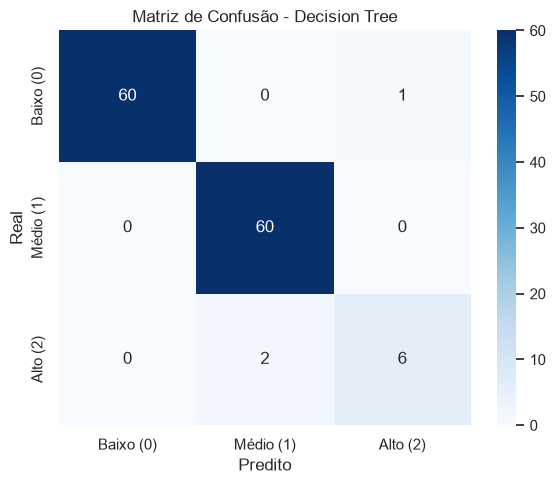


  AVALIAÇÃO: KNN

Métricas principais:
  Acurácia:  0.9767 (97.67%)
  Precisão:  0.9779 (97.79%)
  Recall:    0.9767 (97.67%)
  F1-Score:  0.9759 (97.59%)

Relatório de Classificação:
              precision    recall  f1-score   support

           0     1.0000    0.9836    0.9917        61
           1     0.9524    1.0000    0.9756        60
           2     1.0000    0.7500    0.8571         8

    accuracy                         0.9767       129
   macro avg     0.9841    0.9112    0.9415       129
weighted avg     0.9779    0.9767    0.9759       129



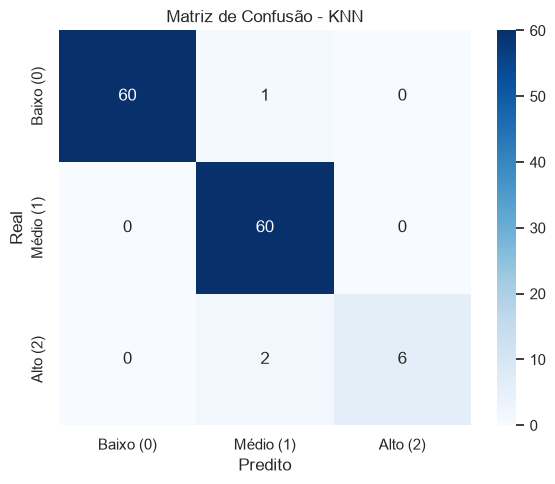


  AVALIAÇÃO: Random Forest

Métricas principais:
  Acurácia:  0.9845 (98.45%)
  Precisão:  0.9847 (98.47%)
  Recall:    0.9845 (98.45%)
  F1-Score:  0.9835 (98.35%)

Relatório de Classificação:
              precision    recall  f1-score   support

           0     0.9839    1.0000    0.9919        61
           1     0.9836    1.0000    0.9917        60
           2     1.0000    0.7500    0.8571         8

    accuracy                         0.9845       129
   macro avg     0.9892    0.9167    0.9469       129
weighted avg     0.9847    0.9845    0.9835       129



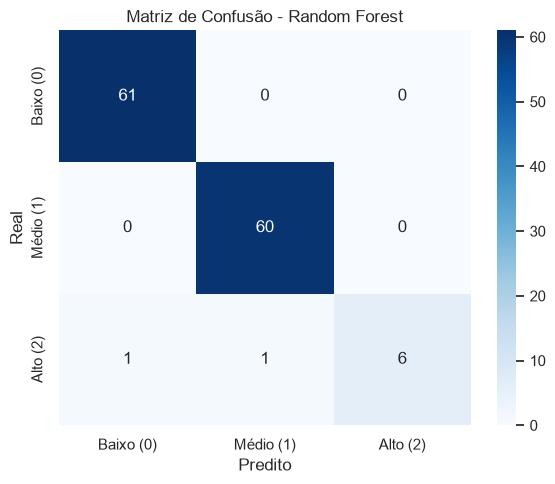

In [16]:
def avaliar_modelo(nome, y_true, y_pred):
    """Avalia o modelo exibindo métricas completas e matriz de confusão."""
    print(f'\n{"=" * 60}')
    print(f'  AVALIAÇÃO: {nome}')
    print(f'{"=" * 60}')

    acuracia = accuracy_score(y_true, y_pred)
    precisao = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f'\nMétricas principais:')
    print(f'  Acurácia:  {acuracia:.4f} ({acuracia*100:.2f}%)')
    print(f'  Precisão:  {precisao:.4f} ({precisao*100:.2f}%)')
    print(f'  Recall:    {recall:.4f} ({recall*100:.2f}%)')
    print(f'  F1-Score:  {f1:.4f} ({f1*100:.2f}%)')

    print(f'\nRelatório de Classificação:')
    print(classification_report(y_true, y_pred, digits=4))

    # Matriz de Confusão
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Baixo (0)', 'Médio (1)', 'Alto (2)'],
                yticklabels=['Baixo (0)', 'Médio (1)', 'Alto (2)'])
    plt.title(f'Matriz de Confusão - {nome}', fontsize=12)
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

    return {'acuracia': acuracia, 'precisao': precisao,
            'recall': recall, 'f1_score': f1}


# Avaliar todos os modelos
metricas_dt = avaliar_modelo('Decision Tree', y_test, y_pred_dt)
metricas_knn = avaliar_modelo('KNN', y_test, y_pred_knn)
metricas_rf = avaliar_modelo('Random Forest', y_test, y_pred_rf)

In [17]:
# Comparação final entre os modelos
print('=' * 60)
print('  COMPARAÇÃO FINAL: Decision Tree vs KNN vs Random Forest')
print('=' * 60)

comparacao = pd.DataFrame({
    'Decision Tree': [
        f'{metricas_dt["acuracia"]*100:.2f}%',
        f'{metricas_dt["precisao"]*100:.2f}%',
        f'{metricas_dt["recall"]*100:.2f}%',
        f'{metricas_dt["f1_score"]*100:.2f}%'
    ],
    'KNN': [
        f'{metricas_knn["acuracia"]*100:.2f}%',
        f'{metricas_knn["precisao"]*100:.2f}%',
        f'{metricas_knn["recall"]*100:.2f}%',
        f'{metricas_knn["f1_score"]*100:.2f}%'
    ],
    'Random Forest': [
        f'{metricas_rf["acuracia"]*100:.2f}%',
        f'{metricas_rf["precisao"]*100:.2f}%',
        f'{metricas_rf["recall"]*100:.2f}%',
        f'{metricas_rf["f1_score"]*100:.2f}%'
    ]
}, index=['Acurácia', 'Precisão', 'Recall', 'F1-Score'])

display(comparacao)

# Determinar o melhor modelo
melhor_f1 = max(metricas_dt['f1_score'], metricas_knn['f1_score'], metricas_rf['f1_score'])
if metricas_rf['f1_score'] == melhor_f1:
    melhor_modelo = 'Random Forest'
elif metricas_dt['f1_score'] == melhor_f1:
    melhor_modelo = 'Decision Tree'
else:
    melhor_modelo = 'KNN'

print(f'\nMelhor modelo (baseado em F1-Score): {melhor_modelo}')
print(f'  - Decision Tree F1: {metricas_dt["f1_score"]*100:.2f}%')
print(f'  - KNN F1:           {metricas_knn["f1_score"]*100:.2f}%')
print(f'  - Random Forest F1: {metricas_rf["f1_score"]*100:.2f}%')

  COMPARAÇÃO FINAL: Decision Tree vs KNN vs Random Forest


,Decision Tree,KNN,Random Forest
Acurácia,97.67%,97.67%,98.45%
Precisão,97.61%,97.79%,98.47%
Recall,97.67%,97.67%,98.45%
F1-Score,97.61%,97.59%,98.35%



Melhor modelo (baseado em F1-Score): Random Forest
  - Decision Tree F1: 97.61%
  - KNN F1:           97.59%
  - Random Forest F1: 98.35%


---
## 6. Exportação dos Artefatos Finais

Os artefatos gerados (modelo treinado e scaler) são serializados para
consumo posterior pela aplicação web Django.

In [18]:
# ============================================================
# 6. EXPORTAÇÃO DOS ARTEFATOS FINAIS
# ============================================================

def exportar_modelo(modelo, scaler, features, metricas, nome_base='modelo_estresse_aluno'):
    """Exporta o modelo treinado, o scaler e metadados para arquivos."""
    os.makedirs('models', exist_ok=True)

    caminho_modelo = os.path.join('models', f'{nome_base}.pkl')
    joblib.dump(modelo, caminho_modelo)
    print(f'Modelo salvo em: {caminho_modelo}')

    caminho_scaler = os.path.join('models', f'scaler.pkl')
    joblib.dump(scaler, caminho_scaler)
    print(f'Scaler salvo em: {caminho_scaler}')

    caminho_features = os.path.join('models', f'features.txt')
    with open(caminho_features, 'w', encoding='utf-8') as f:
        for feat in features:
            f.write(f'{feat}\n')
    print(f'Features salvas em: {caminho_features}')

    metadados = {
        'modelo': nome_base,
        'algoritmo': type(modelo).__name__,
        'features': list(features),
        'random_state': RANDOM_STATE,
        'target': TARGET_COLUMN,
        'target_mapping': {'0': 'Baixo', '1': 'Médio', '2': 'Alto'},
        'n_amostras_treino': len(y_train),
        'n_amostras_teste': len(y_test),
        'acuracia_teste': round(metricas['acuracia'], 4),
        'f1_score_teste': round(metricas['f1_score'], 4),
        'dataset': 'StressLevelDataset.csv'
    }

    with open(os.path.join('models', 'metadados.json'), 'w', encoding='utf-8') as f:
        json.dump(metadados, f, indent=2, ensure_ascii=False)
    print(f'Metadados salvos em: models/metadados.json')

    return caminho_modelo


# Selecionar o melhor modelo e exportar
if melhor_modelo == 'Random Forest':
    modelo_final = rf_model
    metricas_final = metricas_rf
elif melhor_modelo == 'Decision Tree':
    modelo_final = dt_model
    metricas_final = metricas_dt
else:
    modelo_final = knn_model
    metricas_final = metricas_knn

print(f'Modelo selecionado para exportação: {melhor_modelo}')
caminho = exportar_modelo(modelo_final, scaler, features_finais, metricas_final)
print(f'\nArtefato final pronto para consumo: {caminho}')

Modelo selecionado para exportação: Random Forest
Modelo salvo em: models\modelo_estresse_aluno.pkl
Scaler salvo em: models\scaler.pkl
Features salvas em: models\features.txt
Metadados salvos em: models/metadados.json

Artefato final pronto para consumo: models\modelo_estresse_aluno.pkl


---
## Conclusão

O notebook concluiu com sucesso todas as etapas de:
1. Carga e inspeção dos dados
2. Limpeza e tratamento (remoção de outliers via IQR)
3. Análise exploratória com histogramas e matriz de correlação
4. Treinamento de três modelos (Decision Tree, KNN e Random Forest)
5. Avaliação comparativa com métricas robustas
6. Exportação do melhor modelo para produção

O modelo exportado em `.pkl` está pronto para ser integrado à aplicação Django.